In [2]:
# TensorFlow deep learning model banane aur train karne ke liye
import tensorflow as tf

# CNN ki layers aur Sequential model banane ke liye
from tensorflow.keras import layers, models

# Graphs aur training results visualize karne ke liye
import matplotlib.pyplot as plt

# Numerical operations aur arrays handle karne ke liye
import numpy as np

# Kaggle se dataset directly download karne ke liye
import kagglehub

# File aur folder paths manage karne ke liye
import os

In [3]:
# KaggleHub ki help se Plant Disease dataset download kar rahe hain.
# Ye function dataset ko local system me download karke uska path return karega.
path = kagglehub.dataset_download("emmarex/plantdisease")

# Dataset kis location par download hua hai wo print karega.
print(path)

C:\Users\Prateek Verma\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1


In [4]:
# Dataset folder ke andar kaun-kaun se folders/files hain wo dekh rahe hain.
# Isse hume pata chalega ki images kis location par stored hain.
print(os.listdir(path))

['PlantVillage']


In [5]:
# Agar dataset ke andar ek aur "PlantVillage" folder hai,
# to uske andar hi actual class folders present honge.
data_dir = os.path.join(path, "PlantVillage")

In [6]:
# Final dataset path print kar rahe hain
print(data_dir)

# Dataset ke andar available saare class folders dekh sakte hain.
print(os.listdir(data_dir))

C:\Users\Prateek Verma\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1\PlantVillage
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'PlantVillage', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus']


In [7]:
# Model ko sabhi images same size me chahiye hoti hain.
# Isliye har image ko 224x224 pixels me resize karenge.
IMG_SIZE = 224

# Ek baar me model kitni images process karega.
# Isse Batch Size kehte hain.
# 32 ek standard aur efficient value hai.
BATCH_SIZE = 32

In [8]:
# Folder se training dataset load kar rahe hain.

train_ds = tf.keras.preprocessing.image_dataset_from_directory(

    data_dir,                      # Dataset ka path

    validation_split=0.2,          # 20% data validation ke liye reserve hoga

    subset="training",             # Sirf training wala 80% data load hoga

    seed=123,                      # Har baar same train-validation split banega

    image_size=(IMG_SIZE, IMG_SIZE),  # Sabhi images ko 224x224 me resize karega

    batch_size=BATCH_SIZE          # Ek batch me 32 images load hongi
)

Found 41276 files belonging to 16 classes.
Using 33021 files for training.


In [9]:
# Validation dataset load kar rahe hain.
# Ye data training me use nahi hoga.
# Sirf model ki performance check karne ke liye use hota hai.

val_ds = tf.keras.preprocessing.image_dataset_from_directory(

    data_dir,

    validation_split=0.2,

    subset="validation",           # Sirf validation wala 20% data

    seed=123,                      # Same seed taaki split same rahe

    image_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE
)

Found 41276 files belonging to 16 classes.
Using 8255 files for validation.


In [10]:
# Dataset ke folder names automatically class names ban jate hain.

class_names = train_ds.class_names

# Total classes print karenge.
print("Total Classes :", len(class_names))

# Sabhi class names print karenge.
print(class_names)

Total Classes : 16
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'PlantVillage', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [11]:
# AUTOTUNE automatically best settings choose karta hai
# taaki data loading fast ho aur GPU/CPU idle na rahe.

AUTOTUNE = tf.data.AUTOTUNE

# Prefetch():
# Jab model current batch par train ho raha hota hai,
# tab next batch background me ready hota rehta hai.
# Isse training fast ho jati hai.
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

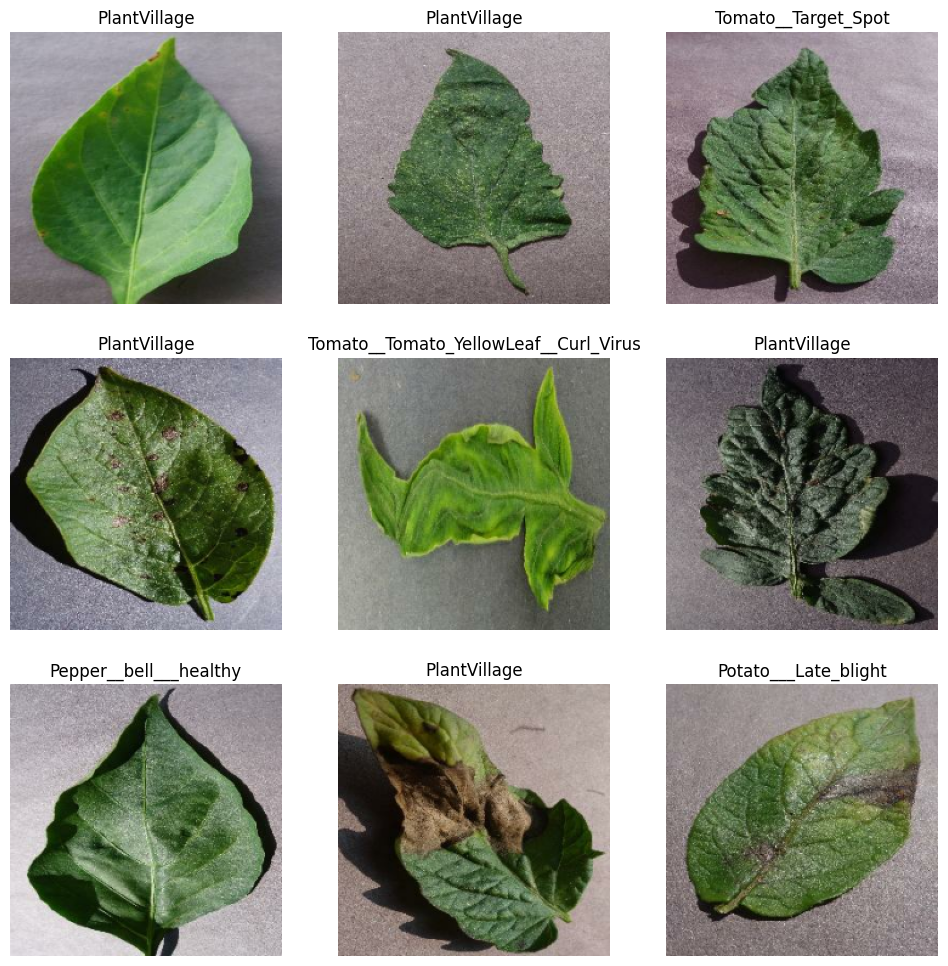

In [12]:
# Dataset se ek batch lekar kuch sample images display karenge.
# Isse verify ho jayega ki images aur labels sahi load hue hain.

plt.figure(figsize=(12, 12))

for images, labels in train_ds.take(1):

    # First 9 images display karenge.
    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        # Image show karega.
        plt.imshow(images[i].numpy().astype("uint8"))

        # Image ka class name title me show karega.
        plt.title(class_names[labels[i]])

        # Axis hide kar denge taaki image clean dikhe.
        plt.axis("off")
        

In [13]:
# Data Augmentation ek technique hai jisme hum original images ke
# different versions banate hain jaise Flip, Rotate aur Zoom.

# Isse naye images create nahi hote, balki training ke time
# image ke different variations model ko dikhaye jate hain.

# Fayde:
# ✅ Model ko alag-alag angles se images dekhne ko milti hain.
# ✅ Overfitting kam hoti hai.
# ✅ Accuracy improve hoti hai.
# ✅ Model real-world images par better perform karta hai.

# Data Augmentation pipeline bana rahe hain.
# Ye sirf training ke time apply hogi.

data_augmentation = tf.keras.Sequential([

    # Image ko randomly left-right flip karega.
    layers.RandomFlip("horizontal"),

    # Image ko randomly ±20% tak rotate karega.
    layers.RandomRotation(0.2),

    # Image ko randomly zoom in/out karega.
    layers.RandomZoom(0.2),

    # Image ki brightness thodi kam ya zyada karega.
    layers.RandomBrightness(0.2),

    # Image ka contrast randomly change karega.
    layers.RandomContrast(0.2)
])

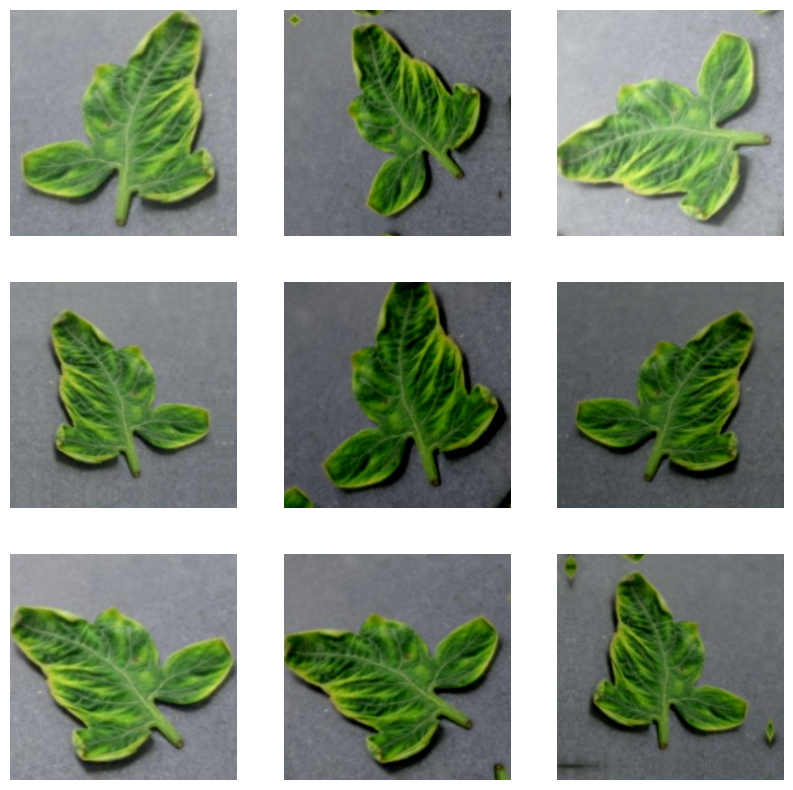

In [14]:
# Ek image ke different augmented versions dekhte hain.

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    first_image = images[0]

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        # Training=True likhne se augmentation apply hogi.
        augmented_image = data_augmentation(
            tf.expand_dims(first_image,0),
            training=True
        )

        plt.imshow(augmented_image[0].numpy().astype("uint8"))

        plt.axis("off")
        

In [15]:
# Original images ke pixel values 0 se 255 ke beech hoti hain.

# Neural Network ke liye itni badi values achhi nahi hoti.

# Isliye hum pixels ko 0-1 range me convert karte hain.

# Formula:

# New Pixel Value = Pixel Value / 255

# Example:

# 255 → 1.0

# 128 → 0.50

# 64 → 0.25

# Is process ko Image Normalization kehte hain.

# Pixel values ko automatically 0-1 range me convert karega.

normalization = layers.Rescaling(1./255)

In [16]:
# Ek image ke minimum aur maximum pixel values check karte hain.

for images, labels in train_ds.take(1):

    image = normalization(images)

    print("Minimum Pixel Value :", tf.reduce_min(image).numpy())

    print("Maximum Pixel Value :", tf.reduce_max(image).numpy())

Minimum Pixel Value : 0.0
Maximum Pixel Value : 0.99353766


In [17]:
# Transfer Learning ek Deep Learning technique hai.

# Normally agar hum CNN model scratch se banaye,
# to hume lakhon images aur bahut zyada training time chahiye hota hai.

# Lekin Transfer Learning me hum ek aisa model use karte hain
# jo pehle se hi bahut bade dataset (ImageNet) par train ho chuka hota hai.

# ImageNet me lagbhag 14 million images aur 1000 classes hoti hain.

# Isliye model pehle hi important features jaise
# Edges, Shapes, Colors aur Textures seekh chuka hota hai.

# Ab hume sirf apne Plant Disease dataset ke according
# model ko thoda sa train (Fine Tune) karna hota hai.

# Fayde:
# ✅ Kam training time
# ✅ Kam data me bhi achhi accuracy
# ✅ Better performance

In [18]:
#Load Pre-trained MobileNetV2

# MobileNetV2 ek lightweight aur fast CNN model hai.
# Ye ImageNet dataset par pehle se trained hai.

base_model = tf.keras.applications.MobileNetV2(

    # Input image size (224 x 224) with RGB channels
    input_shape=(IMG_SIZE, IMG_SIZE, 3),

    # Original ImageNet classifier remove kar rahe hain.
    # Hum apna classifier add karenge.
    include_top=False,

    # ImageNet ke pre-trained weights load honge.
    weights="imagenet"
)

In [19]:
#Freeze the Base Model

# Abhi MobileNetV2 ke saare weights freeze kar rahe hain.
# Matlab training ke time ye update nahi honge.
# Sirf humare naye Dense layers hi train hongi.
# Is process ko Feature Extraction kehte hain.

base_model.trainable = False

In [20]:
# MobileNetV2 image ko directly disease nahi batata.
# Ye image se important features nikalta hai jaise
# →
# Edges
# →
# Corners
# →
# Shapes
# →
# Leaf Texture
# →
# Disease Spots
# →
# Color Patterns

# In sab features ko Feature Maps kehte hain.
# Baad me humari Dense Layers in features ko use karke
# disease predict karti hain.

In [21]:
# Building the CNN Model

# Sequential model me data ek layer se doosri layer tak
# step-by-step pass hota hai.

model = models.Sequential([

    # -------------------------------
    # Step 1 : Data Augmentation
    # -------------------------------

    # Training ke time images ko randomly
    # Flip, Rotate aur Zoom karega.
    # Isse model overfit nahi hoga.
    data_augmentation,


    # -------------------------------
    # Step 2 : Image Normalization
    # -------------------------------

    # Pixel values ko 0-255 se convert karke
    # 0-1 range me le aayega.
    layers.Rescaling(1./255),


    # -------------------------------
    # Step 3 : Feature Extraction
    # -------------------------------

    # MobileNetV2 image ke important features extract karega.
    base_model,


    # -------------------------------
    # Step 4 : Global Average Pooling
    # -------------------------------

    # Large Feature Maps ko ek single feature vector me convert karega.
    # Isse parameters kam hote hain aur overfitting reduce hoti hai.
    layers.GlobalAveragePooling2D(),


    # -------------------------------
    # Step 5 : Batch Normalization
    # -------------------------------

    # Features ko normalize karega.
    # Isse training stable aur fast hoti hai.
    layers.BatchNormalization(),


    # -------------------------------
    # Step 6 : Hidden Layer
    # -------------------------------

    # Dense layer extracted features ko analyse karegi
    # aur disease ke patterns seekhegi.
    layers.Dense(256, activation="relu"),


    # -------------------------------
    # Step 7 : Dropout
    # -------------------------------

    # Randomly 50% neurons ko disable karega.
    # Isse model memorize nahi karega.
    # Overfitting kam hogi.
    layers.Dropout(0.5),


    # -------------------------------
    # Step 8 : Second Hidden Layer
    # -------------------------------

    # Aur complex patterns learn karega.
    layers.Dense(128, activation="relu"),


    # Dobara Dropout
    layers.Dropout(0.3),


    # -------------------------------
    # Step 9 : Output Layer
    # -------------------------------

    # Dataset me jitni classes hain utne neurons honge.

    # Softmax har disease ki probability batayega.

    layers.Dense(len(class_names), activation="softmax")

])

In [22]:
# Model ki architecture dekhne ke liye.
# Isme har layer ka
# →
# Output Shape
# →
# Parameters
# →
# Trainable Parameters
# →
# Non-Trainable Parameters
# show honge.

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (1, 7, 7, 1280)        │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (1, 1280)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (1, 1280)              │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 256)               │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 256)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 128)               │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (1, 128)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (1, 16)                │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,626,000 (10.02 MB)

 Trainable params: 365,456 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [23]:
# Compiling the model

model.compile(

    # Adam optimizer weights ko update karega.
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),

    # Multi-Class Classification ke liye loss function.
    loss="sparse_categorical_crossentropy",

    # Training aur Validation Accuracy show karega.
    metrics=["accuracy"]

)

In [24]:
# Ab model ko training dataset par train kar rahe hain.

history = model.fit(

    # Training Dataset
    train_ds,

    # Har epoch ke baad validation data par
    # model ki performance check karega.
    validation_data=val_ds,

    # Pura training dataset
    # 10 baar model ke through pass hoga.
    epochs=10

)

Epoch 1/10


c:\Users\Prateek Verma\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1032/1032 ━━━━━━━━━━━━━━━━━━━━ 809s 780ms/step - accuracy: 0.4128 - loss: 1.9404 - val_accuracy: 0.5024 - val_loss: 1.2831
Epoch 2/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 753s 729ms/step - accuracy: 0.4650 - loss: 1.4626 - val_accuracy: 0.4985 - val_loss: 1.1490
Epoch 3/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 785s 761ms/step - accuracy: 0.4746 - loss: 1.3325 - val_accuracy: 0.4898 - val_loss: 1.1001
Epoch 4/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 765s 742ms/step - accuracy: 0.4798 - loss: 1.2514 - val_accuracy: 0.4913 - val_loss: 1.0547
Epoch 5/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 762s 738ms/step - accuracy: 0.4858 - loss: 1.1922 - val_accuracy: 0.4939 - val_loss: 1.0287
Epoch 6/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 750s 727ms/step - accuracy: 0.4882 - loss: 1.1528 - val_accuracy: 0.4864 - val_loss: 1.0097
Epoch 7/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 752s 729ms/step - accuracy: 0.4858 - loss: 1.1254 - val_accuracy: 0.4826 - val_loss: 0.9940
Epoch 8/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 758s 735ms/step - accuracy: 0.4

In [25]:
# History object ke andar kaun-kaun si values store hui hain
# wo dekhne ke liye.

print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


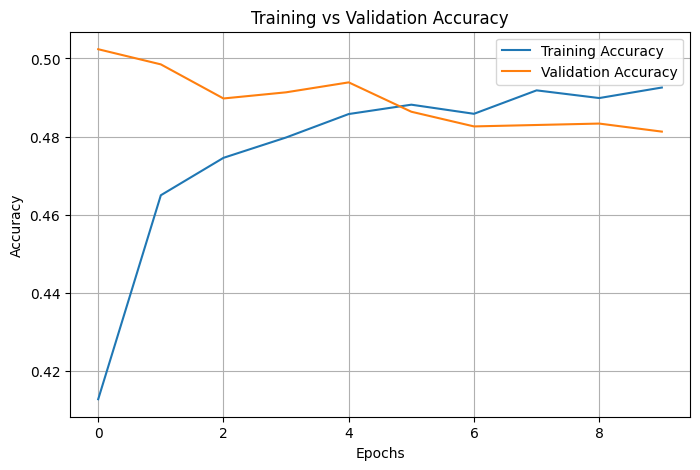

In [26]:
# Training aur Validation Accuracy graph plot kar rahe hain.

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

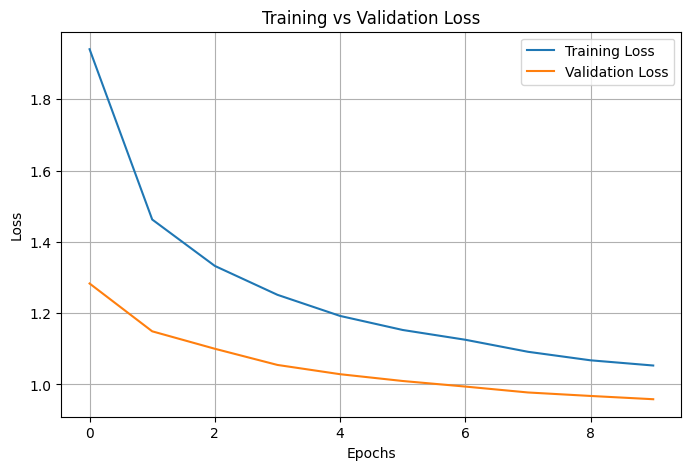

In [27]:
# Training aur Validation Loss graph plot kar rahe hain.

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [28]:
# Pehle humne MobileNetV2 ki saari layers freeze kar di thi.

# Sirf apni Dense Layers train hui thi.

# Ab Fine-Tuning me

# MobileNetV2 ki kuch last layers ko trainable banayenge.

# Isse model Plant Disease images ko aur achhe se samajh payega.

# Fine-Tuning se accuracy generally improve hoti hai.

In [29]:
# Base model ko trainable bana rahe hain.

base_model.trainable = True


# Pehli 100 layers ko freeze rakhenge.

# Sirf last layers hi train hongi.

for layer in base_model.layers[:100]:

    layer.trainable = False

In [30]:
# Fine-Tuning ke liye learning rate aur kam rakhte hain.

# Taaki pre-trained weights me sirf chhote changes aaye.

model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=1e-5

    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [31]:
# Ab model ko dobara train karenge.

# Is baar MobileNetV2 ki last layers bhi learn karengi.

history_fine = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=10

)

Epoch 1/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 1092s 1s/step - accuracy: 0.4893 - loss: 1.1759 - val_accuracy: 0.4813 - val_loss: 1.0833
Epoch 2/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 1097s 1s/step - accuracy: 0.4873 - loss: 1.0643 - val_accuracy: 0.4826 - val_loss: 0.9680
Epoch 3/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 1077s 1s/step - accuracy: 0.4905 - loss: 1.0279 - val_accuracy: 0.4842 - val_loss: 0.9433
Epoch 4/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 1098s 1s/step - accuracy: 0.4954 - loss: 0.9926 - val_accuracy: 0.4815 - val_loss: 0.9159
Epoch 5/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 1105s 1s/step - accuracy: 0.4928 - loss: 0.9752 - val_accuracy: 0.4784 - val_loss: 0.9077
Epoch 6/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 1099s 1s/step - accuracy: 0.4978 - loss: 0.9570 - val_accuracy: 0.4786 - val_loss: 0.8926
Epoch 7/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 1083s 1s/step - accuracy: 0.4920 - loss: 0.9413 - val_accuracy: 0.4793 - val_loss: 0.8785
Epoch 8/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 1065s 1s/step - accuracy: 0.4977 -

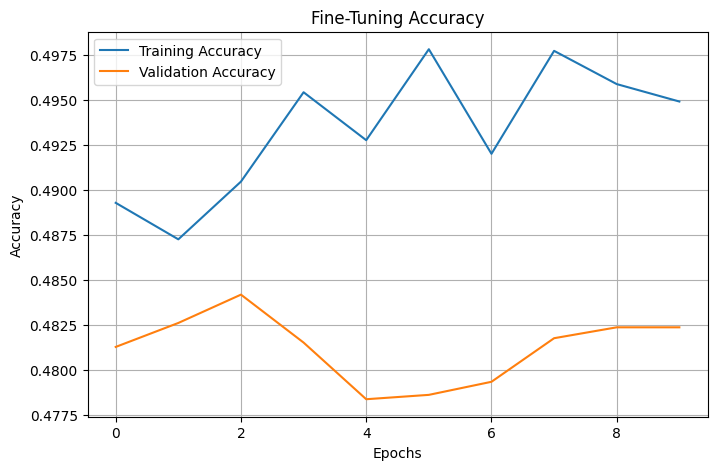

In [32]:
# Fine-Tuning ke baad accuracy graph dekhte hain.

plt.figure(figsize=(8,5))

plt.plot(history_fine.history["accuracy"], label="Training Accuracy")

plt.plot(history_fine.history["val_accuracy"], label="Validation Accuracy")

plt.title("Fine-Tuning Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

In [33]:
# Trained model ko future use ke liye save kar rahe hain.

# Isi model ko Streamlit App me load karenge.

model.save("plant_disease_model.keras")

In [34]:
# Prediction ke time class number ko disease name me convert karne ke liye
# class names save kar rahe hain.

np.save("class_names.npy", class_names)

In [35]:
# Check karte hain ki model aur class names successfully save hue hain ya nahi.

import os

print(os.listdir())

['class_names.npy', 'Plant.ipynb', 'plant_disease_model.keras']


In [1]:
import os
print(os.path.getsize("plant_disease_model.keras") / (1024 * 1024), "MB")

27.641807556152344 MB
